In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

# Chemins
BASE_DIR = Path.cwd().parent
DATA_PATH = BASE_DIR / "data" / "raw" / "creditcard.csv"

assert DATA_PATH.exists(), f"Dataset introuvable: {DATA_PATH}"

# Collecte / chargement
df = pd.read_csv(DATA_PATH)
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print("Shape:", df.shape)
df.columns


Shape: (284807, 31)


Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16',
       'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class'],
      dtype='str')

In [4]:
df.info()

df.isna().sum().sort_values(ascending=False).head(10)


<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

Time    0
V1      0
V2      0
V3      0
V4      0
V5      0
V6      0
V7      0
V8      0
V9      0
dtype: int64

In [5]:
duplicates = df.duplicated().sum()
print("Nombre de doublons:", duplicates)

df = df.drop_duplicates()
print("Shape après suppression des doublons:", df.shape)


Nombre de doublons: 1081
Shape après suppression des doublons: (283726, 31)


Taux de fraude: 0.1667%


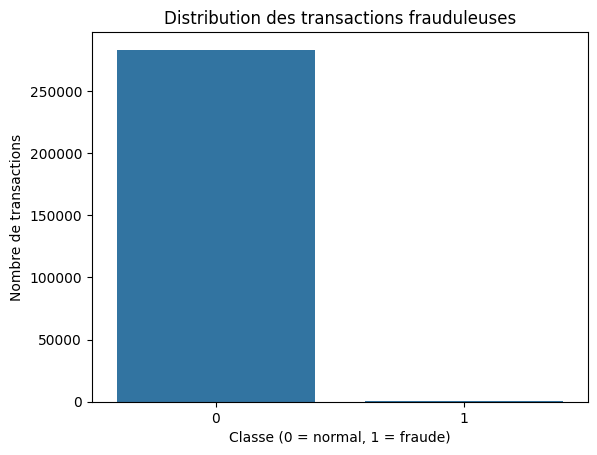

In [6]:
target = "Class"  # 1 = fraude, 0 = normal

df[target].value_counts()

fraud_rate = df[target].mean()
print(f"Taux de fraude: {fraud_rate:.4%}")

sns.countplot(x=target, data=df)
plt.title("Distribution des transactions frauduleuses")
plt.xlabel("Classe (0 = normal, 1 = fraude)")
plt.ylabel("Nombre de transactions")
plt.show()



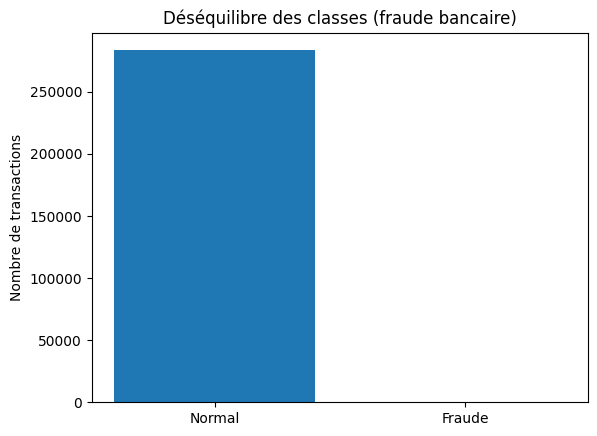

In [7]:
labels = ["Normal", "Fraude"]
counts = df[target].value_counts().values

plt.figure()
plt.bar(labels, counts)
plt.title("Déséquilibre des classes (fraude bancaire)")
plt.ylabel("Nombre de transactions")
plt.show()


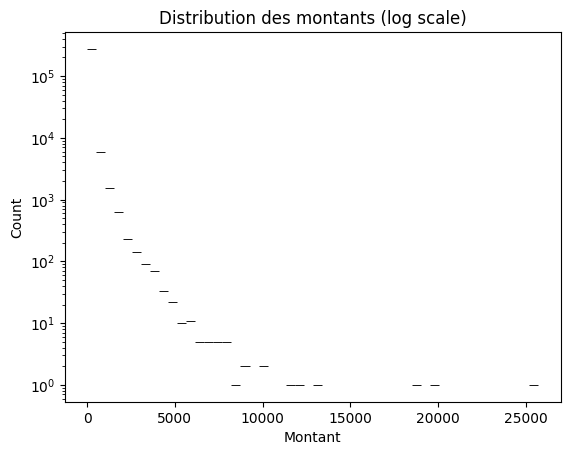

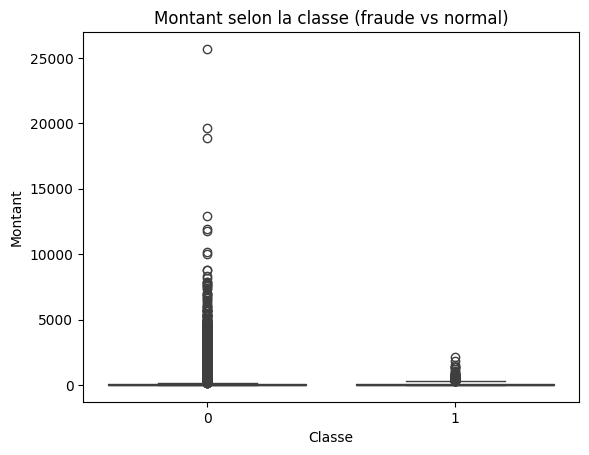

In [8]:
plt.figure()
sns.histplot(df["Amount"], bins=50, log_scale=(False, True))
plt.title("Distribution des montants (log scale)")
plt.xlabel("Montant")
plt.show()

sns.boxplot(x=target, y="Amount", data=df)
plt.title("Montant selon la classe (fraude vs normal)")
plt.xlabel("Classe")
plt.ylabel("Montant")
plt.show()



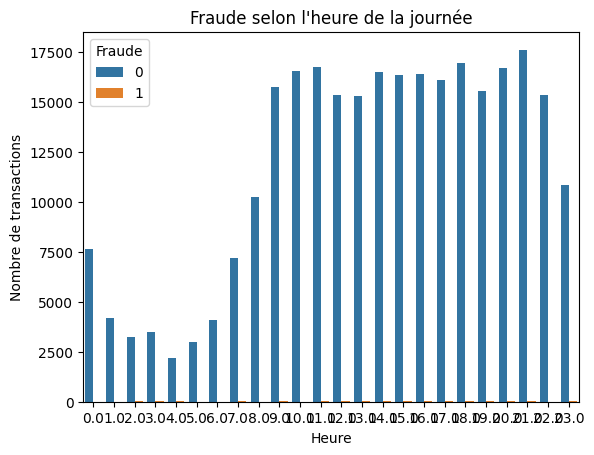

In [9]:
df["Hour"] = (df["Time"] // 3600) % 24

sns.countplot(x="Hour", hue=target, data=df)
plt.title("Fraude selon l'heure de la journée")
plt.xlabel("Heure")
plt.ylabel("Nombre de transactions")
plt.legend(title="Fraude")
plt.show()


In [10]:
X = df.drop(columns=[target])
y = df[target]

print("X shape:", X.shape)
print("y mean (fraude rate):", y.mean())


X shape: (283726, 31)
y mean (fraude rate): 0.001667101358352777


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = X.copy()

X_scaled["Amount"] = scaler.fit_transform(X[["Amount"]])
X_scaled["Time"] = scaler.fit_transform(X[["Time"]])